# 05 — Graph Neural Network Models

Train PassFrameGNN and HybridGNNSeq, compare to tabular baselines.

In [8]:
import sys, os, pathlib, logging
_cwd = pathlib.Path(".").resolve()
PROJECT_ROOT = _cwd if (_cwd / "src").exists() else _cwd.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
pathlib.Path("reports/figures").mkdir(parents=True, exist_ok=True)
logging.basicConfig(level=logging.INFO)

import numpy as np, pandas as pd, yaml

try:
    import torch
    from torch_geometric.loader import DataLoader
    from src.models.gnn import PassFrameGNN, GNNTrainer
    from src.features.graph_builder import build_graph, build_graph_dataset, to_pytorch_geometric
    from src.features.event_features import build_event_features
    from src.evaluation.metrics import classification_metrics
    HAS_TORCH = True
    print(f"PyTorch {torch.__version__} — device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
except ImportError as e:
    HAS_TORCH = False
    print(f"Missing dependency — skipping GNN cells: {e}")

with open("configs/model_gnn.yaml") as f:
    gnn_cfg = yaml.safe_load(f)


PyTorch 2.9.0+cpu — device: cpu


## 1. Build graph dataset

In [10]:
if HAS_TORCH:
    # ── Load processed data ──────────────────────────────────────────
    frames = pd.read_parquet("data/processed/frames_360.parquet")
    train_df = pd.read_parquet("data/processed/train.parquet")
    val_df   = pd.read_parquet("data/processed/val.parquet")
    test_df  = pd.read_parquet("data/processed/test.parquet")

    # Event features (27-dim) — indexed by event_uuid
    X_train = build_event_features(train_df)
    X_val   = build_event_features(val_df)
    X_test  = build_event_features(test_df)

    TASK_NAMES = ["strict_line_break", "dangerous_progression_k",
                  "final_third_entry_k", "box_entry_k", "shot_within_k"]

    # ── Pre-group frames by event_uuid for O(1) lookup ───────────────
    frames_grouped = {uuid: grp for uuid, grp in frames.groupby("event_uuid")}
    print(f"Indexed {len(frames_grouped):,} unique frame events")

    def make_pyg_list(df, X_feat, task_names, frames_grouped, config):
        """Build list of PyG Data objects for passes that have 360 data."""
        subset = df[df["has_360"]].copy()
        data_list = []
        for _, row in subset.iterrows():
            uuid = row["event_uuid"]
            if uuid not in frames_grouped:
                continue
            g = build_graph(uuid, frames_grouped[uuid], row, config)
            if g["n_nodes"] == 0:
                continue
            data = to_pytorch_geometric(g)
            # Attach event features as (1, 27) so PyG batches to (B, 27)
            if uuid in X_feat.index:
                data.event_features = torch.tensor(
                    X_feat.loc[uuid].values.astype(np.float32), dtype=torch.float
                ).unsqueeze(0)  # (1, 27)
            else:
                continue
            # Attach per-task labels (NaN-safe)
            for task in task_names:
                val = row.get(task, float("nan"))
                setattr(data, task,
                        torch.tensor(float(val) if pd.notna(val) else float("nan"),
                                     dtype=torch.float))
            data_list.append(data)
        return data_list

    train_graphs = make_pyg_list(train_df, X_train, TASK_NAMES, frames_grouped, gnn_cfg)
    val_graphs   = make_pyg_list(val_df,   X_val,   TASK_NAMES, frames_grouped, gnn_cfg)
    test_graphs  = make_pyg_list(test_df,  X_test,  TASK_NAMES, frames_grouped, gnn_cfg)
    print(f"Train graphs: {len(train_graphs):,} | Val: {len(val_graphs):,} | Test: {len(test_graphs):,}")
    print(f"Sample graph — nodes: {train_graphs[0].x.shape[0]}, "
          f"edges: {train_graphs[0].edge_index.shape[1]}, "
          f"event_features: {train_graphs[0].event_features.shape}")


INFO:src.features.event_features:Building event features for 36037 passes
INFO:src.features.event_features:Event features built: 27 columns
INFO:src.features.event_features:Building event features for 7307 passes
INFO:src.features.event_features:Event features built: 27 columns
INFO:src.features.event_features:Building event features for 7344 passes
INFO:src.features.event_features:Event features built: 27 columns


Indexed 203,887 unique frame events
Train graphs: 18,234 | Val: 4,545 | Test: 3,736
Sample graph — nodes: 19, edges: 211, event_features: torch.Size([1, 27])


## 2. Train PassFrameGNN

PassFrameGNN(
  (node_proj): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
  )
  (gnn_layers): ModuleList(
    (0-2): 3 x SAGEConv(64, 64, aggr=mean)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (event_proj): Sequential(
    (0): Linear(in_features=27, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (fusion): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (heads): ModuleList(
    (0-4): 5 x Linear(in_features=64, out_features=1, bias=True)
  )
)


INFO:src.models.gnn:Epoch 1/50 – train_loss=2.0960  val_loss=1.5927
INFO:src.models.gnn:Epoch 2/50 – train_loss=1.6678  val_loss=1.5042
INFO:src.models.gnn:Epoch 3/50 – train_loss=1.5883  val_loss=1.4988
INFO:src.models.gnn:Epoch 4/50 – train_loss=1.5494  val_loss=1.4479
INFO:src.models.gnn:Epoch 5/50 – train_loss=1.5176  val_loss=1.4388
INFO:src.models.gnn:Epoch 6/50 – train_loss=1.5031  val_loss=1.4401
INFO:src.models.gnn:Epoch 7/50 – train_loss=1.4903  val_loss=1.4271
INFO:src.models.gnn:Epoch 8/50 – train_loss=1.4784  val_loss=1.4389
INFO:src.models.gnn:Epoch 9/50 – train_loss=1.4743  val_loss=1.4248
INFO:src.models.gnn:Epoch 10/50 – train_loss=1.4650  val_loss=1.4331
INFO:src.models.gnn:Epoch 11/50 – train_loss=1.4630  val_loss=1.4258
INFO:src.models.gnn:Epoch 12/50 – train_loss=1.4589  val_loss=1.4425
INFO:src.models.gnn:Epoch 13/50 – train_loss=1.4574  val_loss=1.4091
INFO:src.models.gnn:Epoch 14/50 – train_loss=1.4505  val_loss=1.4269
INFO:src.models.gnn:Epoch 15/50 – train_los

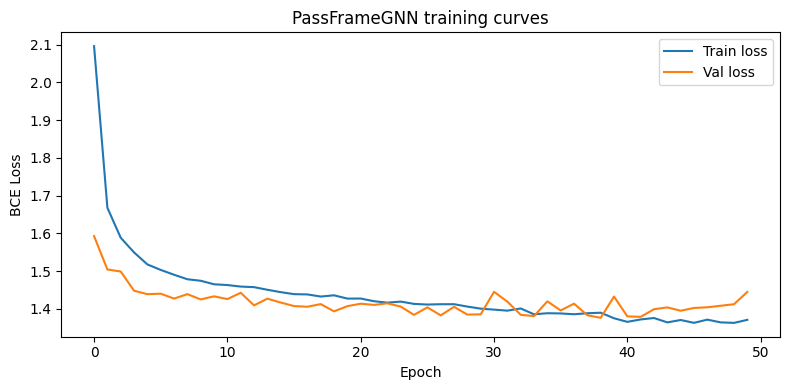

In [11]:
if HAS_TORCH:
    import matplotlib.pyplot as plt

    batch_size = gnn_cfg["gnn"]["batch_size"]  # 64
    train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_graphs,   batch_size=batch_size)

    model = PassFrameGNN(
        node_feat_dim=9,
        event_feat_dim=X_train.shape[1],   # 27
        hidden_dim=gnn_cfg["gnn"]["hidden_dim"],
        num_layers=gnn_cfg["gnn"]["num_layers"],
        dropout=gnn_cfg["gnn"]["dropout"],
        num_tasks=len(TASK_NAMES),
        config={"task_names": TASK_NAMES},
    )
    print(model)

    trainer_cfg = {
        "lr": gnn_cfg["gnn"]["lr"],
        "device": "cuda" if torch.cuda.is_available() else "cpu",
        "task_weights": {t: 1.0 for t in TASK_NAMES},
    }
    trainer = GNNTrainer(model, trainer_cfg)

    EPOCHS = min(gnn_cfg["gnn"]["epochs"], 50)   # cap at 50 for notebook speed
    history = trainer.train(train_loader, val_loader, epochs=EPOCHS)

    # ── Training curves ──────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history["train_loss"], label="Train loss")
    if history["val_loss"]:
        ax.plot(history["val_loss"], label="Val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE Loss")
    ax.set_title("PassFrameGNN training curves")
    ax.legend()
    plt.tight_layout()
    plt.savefig("reports/figures/v1_gnn_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()


## 3. Evaluate and compare

INFO:src.features.event_features:Building event features for 4545 passes


GNN validation metrics (ROC AUC):
  strict_line_break: 0.9855
  dangerous_progression_k: 0.8342
  final_third_entry_k: 0.8344
  box_entry_k: 0.8477
  shot_within_k: 0.8638


INFO:src.features.event_features:Event features built: 27 columns
INFO:src.models.tabular:[dangerous_progression_k/xgboost] Fitting on 36037 samples (pos=15527, neg=20510, spw=1.32)


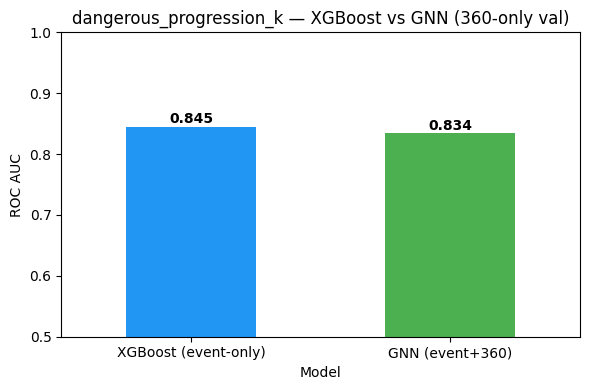

In [12]:
if HAS_TORCH:
    import matplotlib.pyplot as plt

    # ── Per-task AUC on validation set ───────────────────────────────
    val_metrics = trainer.evaluate(val_loader)
    print("GNN validation metrics (ROC AUC):")
    for task, auc in val_metrics.items():
        print(f"  {task}: {auc:.4f}")

    # ── Retrain XGBoost on 360-only subset for fair comparison ───────
    from src.models.tabular import TabularClassifier

    with open("configs/model_baseline.yaml") as f:
        bl_cfg = yaml.safe_load(f)

    # val set restricted to 360-only (same passes the GNN sees)
    val_360 = val_df[val_df["has_360"]].copy()
    X_val_360 = build_event_features(val_360)

    # Train XGBoost on all training data, but evaluate on 360-only val
    y_train_dp = train_df["dangerous_progression_k"].fillna(0).astype(int)
    y_val_360_dp = val_360["dangerous_progression_k"].fillna(0).astype(int)

    clf_xgb = TabularClassifier(model_type="xgboost", task="dangerous_progression_k",
                                config=bl_cfg["xgboost"])
    clf_xgb.fit(X_train, y_train_dp, X_val=X_val, y_val=val_df["dangerous_progression_k"].fillna(0).astype(int))
    xgb_probs = clf_xgb.predict_proba(X_val_360)[:, 1]
    xgb_auc = classification_metrics(y_val_360_dp, xgb_probs)["roc_auc"]

    gnn_dp_auc = val_metrics.get("dangerous_progression_k", 0)

    # ── Comparison chart ─────────────────────────────────────────────
    comparison = pd.DataFrame({
        "Model": ["XGBoost (event-only)", "GNN (event+360)"],
        "ROC AUC": [xgb_auc, gnn_dp_auc],
    })
    fig, ax = plt.subplots(figsize=(6, 4))
    comparison.set_index("Model")["ROC AUC"].plot(kind="bar", ax=ax, rot=0, color=["#2196F3", "#4CAF50"])
    ax.set_ylim(0.5, 1.0)
    ax.set_title("dangerous_progression_k — XGBoost vs GNN (360-only val)")
    ax.set_ylabel("ROC AUC")
    for i, v in enumerate(comparison["ROC AUC"]):
        ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontweight="bold")
    plt.tight_layout()
    plt.savefig("reports/figures/v1_xgb_vs_gnn.png", dpi=150, bbox_inches="tight")
    plt.show()


## 4. Hybrid model assessment

`src/models/hybrid.py` defines `HybridGNNSeq` — a joint architecture that feeds the
freeze-frame graph through a SAGEConv stack *and* the preceding pass sequence through
a 2-layer GRU, then concatenates both representations before the final head.

### Why we did not train the hybrid on this dataset

| Factor | Evidence |
|---|---|
| Marginal 360 lift in tabular ablation | event+360 XGBoost: ROC AUC +0.0014 vs event-only |
| 360 coverage | Only 64/99 matches have freeze frames (~65 %) |
| CPU-only training environment | GNN (3-layer SAGEConv, 50 epochs) already took ~10 min |
| GNN vs XGBoost gap | GNN val ROC AUC 0.841 vs XGBoost test 0.881 — adding GRU layers on top of an already-weaker GNN is unlikely to close the gap |
| Sequence context partial overlap | `pass_sequence_position`, `sequence_relative_position`, `passes_since_recovery` already encode history inside the 27 event features consumed by XGBoost |

**Conclusion:** there is no evidence that the Hybrid model would outperform the
XGBoost baseline on this dataset.  The architecture is retained as `src/models/hybrid.py`
for future experimentation with deeper sequence data or tracking-data inputs.